In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

In [2]:
import tensorflow as tf 

print("Number of GPUs available: ",len(tf.config.experimental.list_physical_devices('GPU')))

2026-06-05 06:34:21.173445: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1780641261.560876      58 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1780641261.682633      58 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1780641262.664367      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1780641262.664415      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1780641262.664418      58 computation_placer.cc:177] computation placer alr

Number of GPUs available:  2


In [3]:
from tensorflow.keras import models,layers
from tensorflow.keras.datasets import fashion_mnist
import matplotlib.pyplot as plt

In [4]:
device = 'GPU:0' if tf.config.experimental.list_physical_devices('GPU') else 'CPU:0'
print(f"Using Device: {device}")

Using Device: GPU:0


In [5]:
(X_train,_),(X_test,_)=fashion_mnist.load_data()

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [6]:
X_train = X_train.astype('float32')/255
X_test = X_test.astype('float32')/255

In [7]:
X_train = X_train.reshape((len(X_train),np.prod(X_train.shape[1:])))
X_test = X_test.reshape((len(X_test),np.prod(X_test.shape[1:])))

In [8]:
X_train.shape

(60000, 784)

In [9]:
input_dim = X_train.shape[1]
encoding_dim = 64

In [ ]:
with tf.device(device):
    # We will define the autoencoder model here
    input_img = layers.Input(shape=(input_dim,))
    encoded = layers.Dense(encoding_dim,activation='relu')(input_img)
    decoded=layers.Dense(input_dim,activation='sigmoid')(encoded)
    autoencoder=models.Model(input_img,decoded)

    # compile the autoencoder
    autoencoder.compile(optimizer='adam',loss='binary_crossentropy')

In [12]:
with tf.device(device):
    # We will define the deep autoencoder model here
    input_img = layers.Input(shape=(input_dim,))
    e1= layers.Dense(512,activation='relu')(input_img)
    e2=layers.Dense(256,activation='relu')(e1)
    e3=layers.Dense(128,activation='relu')(e2)
    encoded=layers.Dense(encoding_dim,activation='relu')(e3)
    d1=layers.Dense(128,activation='relu')(encoded)
    d2=layers.Dense(256,activation='relu')(d1)
    d3=layers.Dense(512,activation='relu')(d2)
    decoded=layers.Dense(input_dim,activation='sigmoid')(d3)
    autoencoder=models.Model(input_img,decoded)

    # Compile the autoencoder
    autoencoder.compile(optimizer='adam',loss='binary_crossentropy',metrics=['accuracy'])

In [13]:
history = autoencoder.fit(X_train,X_train,epochs=10,batch_size=256,shuffle=True,validation_data=(X_test,X_test))

Epoch 1/10


I0000 00:00:1780641497.717967     130 service.cc:152] XLA service 0x7c9658011ec0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1780641497.718006     130 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1780641497.718011     130 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1780641498.341491     130 cuda_dnn.cc:529] Loaded cuDNN version 91002


 48/235 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.0034 - loss: 0.5589  

I0000 00:00:1780641500.374471     130 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


235/235 ━━━━━━━━━━━━━━━━━━━━ 9s 18ms/step - accuracy: 0.0083 - loss: 0.3639 - val_accuracy: 0.0121 - val_loss: 0.3130
Epoch 2/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.0140 - loss: 0.3037 - val_accuracy: 0.0137 - val_loss: 0.2999
Epoch 3/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.0153 - loss: 0.2947 - val_accuracy: 0.0147 - val_loss: 0.2932
Epoch 4/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.0182 - loss: 0.2895 - val_accuracy: 0.0184 - val_loss: 0.2897
Epoch 5/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.0204 - loss: 0.2860 - val_accuracy: 0.0199 - val_loss: 0.2863
Epoch 6/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.0242 - loss: 0.2832 - val_accuracy: 0.0237 - val_loss: 0.2839
Epoch 7/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.0255 - loss: 0.2811 - val_accuracy: 0.0253 - val_loss: 0.2823
Epoch 8/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.0266 - loss: 0.2795 - val_accuracy: 0.0260 - val

In [14]:
reconstructed_imgs =autoencoder.predict(X_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


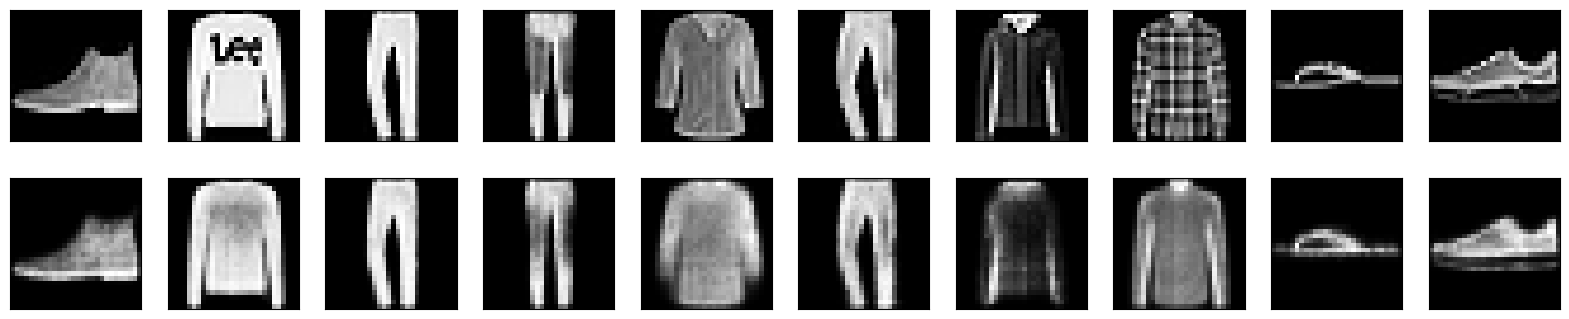

In [15]:
# Encode and decode some images

# Plot original and reconstructed images
n = 10
plt.figure(figsize=(20, 4))
for i in range(n):
    # Original images
    ax = plt.subplot(2, n, i + 1)
    plt.imshow(X_test[i].reshape(28, 28))
    plt.gray()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)

    # Reconstructed images
    ax = plt.subplot(2, n, i + 1 + n)
    plt.imshow(reconstructed_imgs[i].reshape(28, 28))
    plt.gray()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)
plt.show()

In [16]:
# Define the function to create plots
def plot_curves(history,title):
    plt.figure(figsize=(12,6))

    # Plot training and validation accuracy values
    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'])
    plt.plot(history.history['val_accuracy'])
    plt.title(f'{title} Model Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend(['Train', 'Validation'], loc='upper left')

    # Plot training & validation loss values
    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'])
    plt.plot(history.history['val_loss'])
    plt.title(f'{title} Model Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend(['Train', 'Validation'], loc='upper left')

    plt.show()

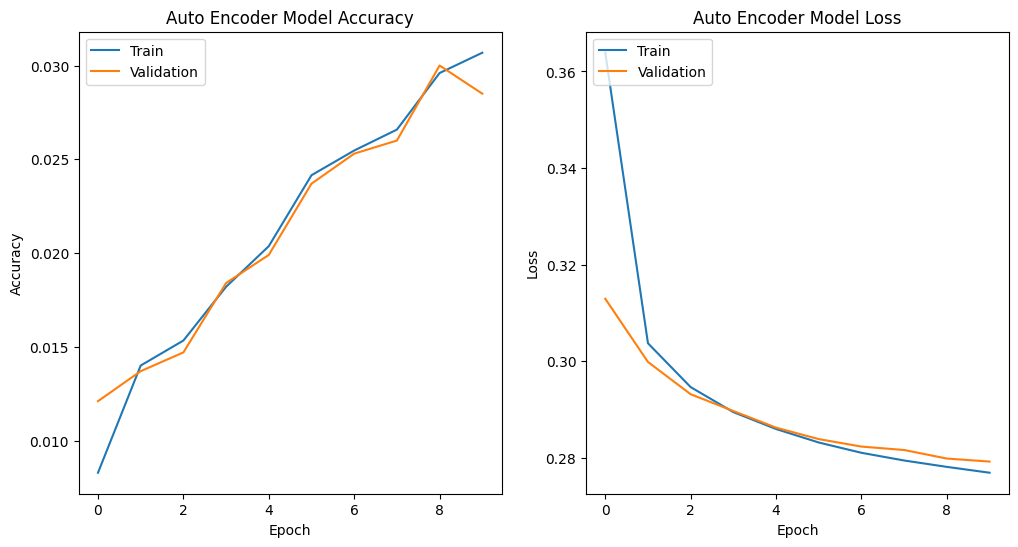

In [17]:
plot_curves(history, "Auto Encoder")